# Machine Learning in Computational Biology — Assignment #1

This notebook contains the full pipeline for epigenetic age prediction from DNA methylation data.

All reusable functions are implemented in `src/functions.py`. We import them here to keep the notebook clean and readable.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
sys.path.append('../src')
from functions import *
print('All functions loaded successfully!')

All functions loaded successfully!


---
# Task 1: Data Loading and Preprocessing

In this task we load the data, build our preprocessing pipeline, and explore the dataset.

The dataset comes from GSE40279 (Hannum et al., 2013) — whole-blood DNA methylation measured with the Illumina 450K microarray. Each sample has 1000 CpG features (beta values 0-1), plus age, sex, and ethnicity.

## 1.1 Data Splitting

We load `development_data.csv` (456 samples) and split it into:
- **80% training** (364 samples) — used for all model training and feature selection
- **20% validation** (92 samples) — used to evaluate design decisions

The split is **stratified by age** using 5 quantile bins with `random_state=42` to ensure reproducibility and balanced age distribution across splits.

`evaluation_data.csv` (100 samples) is loaded separately and treated as completely **locked** — it is never used to make any design decision, select features, or tune hyperparameters. It is only touched in Task 4.2 for final evaluation.

In [2]:
development_df, train_df, val_df, evaluation_df = load_data_preprocessing(
    development_path='../data/development_data.csv',
    evaluation_path='../data/evaluation_data.csv'
)

print(f'\nDevelopment set: {len(development_df)} samples')
print(f'Training set:    {len(train_df)} samples')
print(f'Validation set:  {len(val_df)} samples')
print(f'Evaluation set:  {len(evaluation_df)} samples (LOCKED)')


Loading development dataset

Loading dataset from: ../data/development_data.csv
The first rows of the dataset             age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.

## 1.2 Preprocessing Pipeline

### Step 1: Inspect Missing Values

Before building the pipeline we check how many missing values exist in each split.

In [3]:
print('=== TRAIN ===')
check_missing_values(train_df)
print('\n=== VALIDATION ===')
check_missing_values(val_df)
print('\n=== EVALUATION ===')
check_missing_values(evaluation_df)

=== TRAIN ===

Checking missing values
Total missing values: 10965

Missing values in column: cg26330518    26
cg04193015    24
cg12233363    22
cg27314669    21
cg25410668    20
cg01804382    20
cg24998110    20
cg08128734    20
cg04999352    20
cg07234388    20
dtype: int64

=== VALIDATION ===

Checking missing values
Total missing values: 2747

Missing values in column: cg01493685    9
cg07539927    8
cg15903032    8
cg25410668    8
cg03236802    8
cg09001514    7
cg10221746    7
cg04431935    7
cg12623930    7
cg26161329    7
dtype: int64

=== EVALUATION ===

Checking missing values
Total missing values: 3058

Missing values in column: cg12233363    10
cg26553501     9
cg03013070     9
cg11419186     9
cg10891482     9
cg10979567     9
cg20520262     8
cg11367633     8
cg14794655     8
cg04709900     8
dtype: int64


### Missing Value Strategy: Median Imputation

The missing values are **MCAR (Missing Completely At Random)** — the missingness is unrelated to the true value or any other variable in the dataset.

We chose **median imputation** for the following reasons:
1. CpG methylation beta values can be skewed — median is more robust to outliers than mean
2. Under MCAR, median imputation does not introduce systematic bias into the data
3. It is simple and widely used in methylation studies

**Important**: The imputer is **fit exclusively on the training set** and then applied (transform-only) to the validation and evaluation sets. Fitting on the full dataset would constitute data leakage and lead to optimistically biased results.

### Step 2: Feature Scaling

We apply `StandardScaler` to all CpG features inside a sklearn `Pipeline`. This ensures zero mean and unit variance, which is important for regularised models like ElasticNet and SVR.

### Step 3: Categorical Features

`sex` and `ethnicity` are categorical — we encode them with `OneHotEncoder`. This converts categories to binary columns that models can use numerically.

Whether these variables add predictive signal for age is an empirical question — we test it in Task 2 by comparing three feature combinations.

In [4]:
metadata_cols, cpg_cols, target_col = get_feature_groups(train_df)
print('Metadata columns:', metadata_cols)
print('Number of CpG columns:', len(cpg_cols))
print('Target column:', target_col)

Metadata columns: ['sex', 'ethnicity']
Number of CpG columns: 1000
Target column: age


### Feature Matrices

We construct **3 feature combinations** to understand how much predictive signal comes from different sources:

| Feature set | Columns | Purpose |
|---|---|---|
| **metadata only** | sex, ethnicity (→ 4 one-hot) | Demographic baseline — what can age predict from demographics alone? |
| **cpg only** | 1000 CpG features | Methylation signal — our main source of information |
| **all** | metadata + CpG (1004 total) | Combined — does adding demographics improve CpG predictions? |

In [5]:
for feature_name in ['metadata', 'cpg', 'all']:
    feature_cols     = get_feature_set(train_df, feature_set=feature_name)
    X_train, y_train = split_features_target(train_df, feature_cols)
    X_val,   y_val   = split_features_target(val_df,   feature_cols)
    selected_meta    = [c for c in metadata_cols if c in feature_cols]
    selected_cpg     = [c for c in cpg_cols      if c in feature_cols]
    preprocessor     = build_preprocessor(selected_cpg, selected_meta)
    X_train_p        = preprocessor.fit_transform(X_train)
    X_val_p          = preprocessor.transform(X_val)
    print(f'\n{feature_name.upper()}: X_train={X_train_p.shape}, X_val={X_val_p.shape}')


METADATA: X_train=(364, 4), X_val=(92, 4)

CPG: X_train=(364, 1000), X_val=(92, 1000)

ALL: X_train=(364, 1004), X_val=(92, 1004)


## 1.3 Exploratory Analysis

### Dataset Statistics Table

This table summarises the key properties of each split — sample size, age distribution, and sex balance.

In [6]:
print_stats_table(train_df, val_df, evaluation_df)

     Split   N Age Mean±Std Age Range  Male  Female
     Train 364  64.5 ± 14.6  19 - 101   191     173
Validation  92  64.2 ± 14.7   25 - 89    41      51
Evaluation 100  62.5 ± 14.3   21 - 92    42      58


### Age Distribution — Development Set

The age distribution of the full development set (train + validation). This gives us an overview of the age range we are trying to predict.

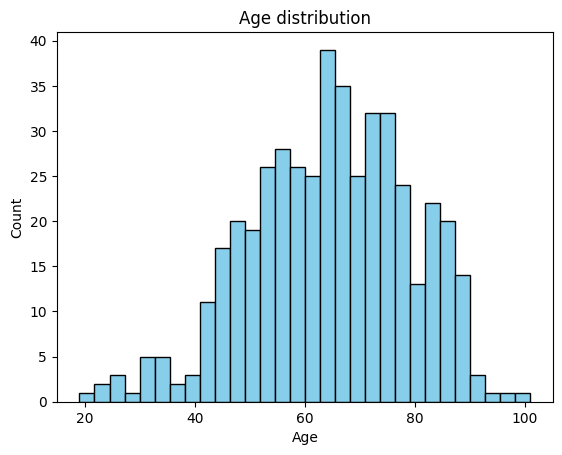

In [7]:
plot_age_histogram(development_df['age'])

### Age Distribution — All Three Splits

We verify that the stratified split produced balanced age distributions across train, validation, and evaluation sets.

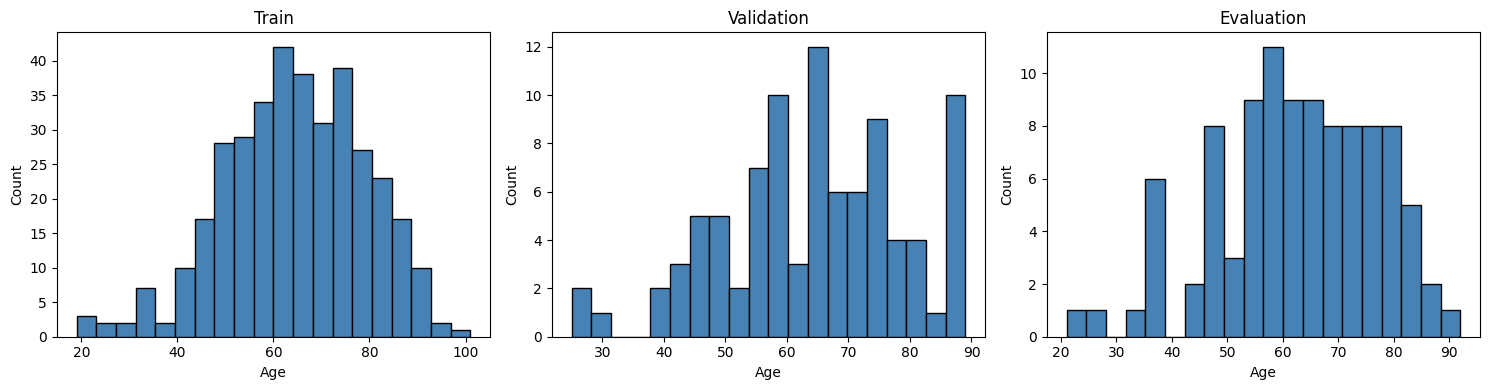

In [8]:
plot_age_by_split(train_df, val_df, evaluation_df)

### Detailed Dataset Summaries

In [9]:
dataset_summary(train_df, 'Training set')
dataset_summary(val_df, 'Validation set')
dataset_summary(evaluation_df, 'Evaluation set')


Dataset: Training set
Number of samples: 364
Age mean: 64.51
Age std: 14.64
Age range: 19 - 101

Sex balance:
sex
M    191
F    173
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    246
Hispanic - Mexican      118
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 10965

Dataset: Validation set
Number of samples: 92
Age mean: 64.22
Age std: 14.69
Age range: 25 - 89

Sex balance:
sex
F    51
M    41
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    62
Hispanic - Mexican      30
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 2747

Dataset: Evaluation set
Number of samples: 100
Age mean: 62.5
Age std: 14.35
Age range: 21 - 92

Sex balance:
sex
F    58
M    42
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    56
Hispanic - Mexican      44
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 3058


### Justification Summary

**Missing values:** Median imputation was chosen because CpG methylation values can be skewed, making median more robust than mean. Under MCAR, this strategy does not introduce bias. The imputer is always fit only on training data to prevent leakage.

**Categorical features:** `sex` and `ethnicity` are one-hot encoded so models can use them numerically. We test their predictive value in Task 2.

**Feature matrices:** Three combinations (metadata only / CpG only / all) allow us to isolate the contribution of each data source.

**No additional cleaning:** No duplicate rows or clearly erroneous values were detected beyond the expected NaN values.

---
# Task 2: Baseline Models

We establish performance baselines before any feature selection or tuning. Every subsequent model must beat these baselines to justify its inclusion.

## 2.1 OLS Linear Regression

OLS provides a simple, interpretable, unregularised baseline. We train it on all three feature combinations to understand how much signal each source contributes.

Training: single fit on training set — **no cross-validation, no tuning**.

Evaluation: **1000 bootstrap resamples** of the validation set, `seed=42`. We report RMSE, MAE, R², and Pearson r with 95% confidence intervals.

In [10]:
for feature_name in ['metadata', 'cpg', 'all']:
    print(f'\n=== OLS - {feature_name.upper()} ===')
    feature_cols      = get_feature_set(train_df, feature_set=feature_name)
    X_train, y_train  = split_features_target(train_df, feature_cols)
    X_val,   y_val    = split_features_target(val_df,   feature_cols)
    selected_meta     = [c for c in metadata_cols if c in feature_cols]
    selected_cpg      = [c for c in cpg_cols      if c in feature_cols]
    preprocessor      = build_preprocessor(selected_cpg, selected_meta)
    X_train_p         = preprocessor.fit_transform(X_train)
    X_val_p           = preprocessor.transform(X_val)
    y_pred            = train_ols_model(X_train_p, y_train, X_val_p)
    ols_rmse, ols_r2  = evaluate_model(y_val, y_pred)


=== OLS - METADATA ===

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 12.9545 (95% CI: 10.5730 - 15.4597)
MAE: 9.8540 (95% CI: 8.2067 - 11.7093)
R^2: 0.2138 (95% CI: 0.0510 - 0.3648)
Pearson r: 0.4629 (95% CI: 0.2991 - 0.6253)

=== OLS - CPG ===

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.2731 (95% CI: 4.0635 - 6.5458)
MAE: 4.0006 (95% CI: 3.2965 - 4.6899)
R^2: 0.8697 (95% CI: 0.7875 - 0.9235)
Pearson r: 0.9355 (95% CI: 0.8930 - 0.9650)

=== OLS - ALL ===

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.2576 (95% CI: 4.0582 - 6.5256)
MAE: 3.9915 (95% CI: 3.2988 - 4.6716)
R^2: 0.8705 (95% CI: 0.7878 - 0.9243)
Pearson r: 0.9360 (95% CI: 0.8937 - 0.9654)


## 2.2 Three Regression Models at Default Hyperparameters

We train three algorithms on the **CpG-only** feature set (1000 features) at sklearn default hyperparameters:

- **ElasticNet** — L1+L2 regularised linear regression
- **SVR** — Support Vector Regression with RBF kernel
- **BayesianRidge** — Bayesian linear regression with automatic relevance determination

Same bootstrap evaluation protocol as Task 2.1.

In [11]:
feature_cols      = get_feature_set(train_df, feature_set='cpg')
X_train, y_train  = split_features_target(train_df, feature_cols)
X_val,   y_val    = split_features_target(val_df,   feature_cols)
selected_cpg      = [c for c in cpg_cols if c in feature_cols]
preprocessor      = build_preprocessor(selected_cpg, [])
X_train_p         = preprocessor.fit_transform(X_train)
X_val_p           = preprocessor.transform(X_val)

In [12]:
print('=== ElasticNet (default hyperparameters) ===')
y_pred_elastic           = train_elastic_net_model(X_train_p, y_train, X_val_p)
elastic_rmse, elastic_r2 = evaluate_model(y_val, y_pred_elastic)

=== ElasticNet (default hyperparameters) ===
Elastic_net model
Elastic Net model trained successfully.
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.5131 (95% CI: 4.3695 - 6.8731)
MAE: 4.0937 (95% CI: 3.3488 - 4.8785)
R^2: 0.8576 (95% CI: 0.7707 - 0.9109)
Pearson r: 0.9334 (95% CI: 0.8886 - 0.9632)


In [13]:
print('=== SVR with RBF kernel (default hyperparameters) ===')
y_pred_svr         = train_SVR_model(X_train_p, y_train, X_val_p)
svr_rmse, svr_r2   = evaluate_model(y_val, y_pred_svr)

=== SVR with RBF kernel (default hyperparameters) ===
SVR model with RBF kernel
SVR_model succesfully done
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 8.9233 (95% CI: 7.2349 - 10.6252)
MAE: 6.4736 (95% CI: 5.3430 - 7.8107)
R^2: 0.6270 (95% CI: 0.5374 - 0.7041)
Pearson r: 0.8464 (95% CI: 0.7804 - 0.8984)


In [14]:
print('=== BayesianRidge (default hyperparameters) ===')
y_pred_bayes           = train_BayesianRidge_model(X_train_p, y_train, X_val_p)
bayes_rmse, bayes_r2   = evaluate_model(y_val, y_pred_bayes)

=== BayesianRidge (default hyperparameters) ===
Bayesian Ridge model
Bayesian Ridge model traind successfully.
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 4.7284 (95% CI: 3.6219 - 5.9787)
MAE: 3.5355 (95% CI: 2.9191 - 4.1763)
R^2: 0.8953 (95% CI: 0.8252 - 0.9401)
Pearson r: 0.9500 (95% CI: 0.9134 - 0.9734)


### Bootstrap Boxplots — RMSE and R²

Comparing the distribution of bootstrap scores across all three models.

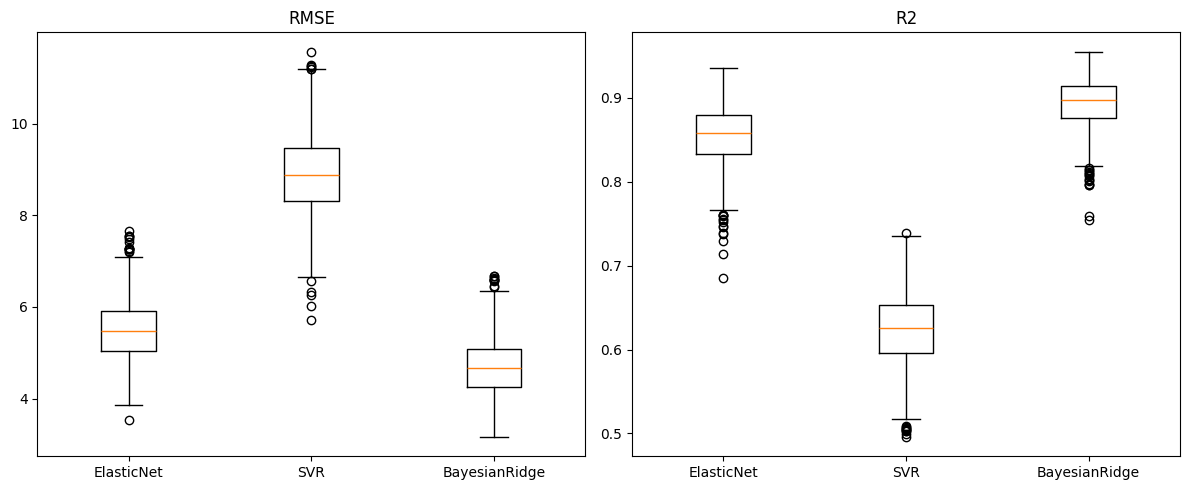

In [15]:
plot_bootstrap_boxplots(
    [elastic_rmse, svr_rmse, bayes_rmse],
    [elastic_r2,   svr_r2,   bayes_r2],
    ['ElasticNet', 'SVR', 'BayesianRidge']
)

### Task 2 Discussion

**OLS metadata only**: Very poor performance. Sex and ethnicity alone have minimal predictive power for age — biological age is not reliably encoded in demographic variables.

**OLS CpG only**: Much better performance. DNA methylation carries a strong and consistent age signal — this confirms that CpG features are the primary source of information.

**OLS all features**: Very similar to CpG only. Adding demographic metadata does not substantially improve predictions, suggesting the age signal is dominated by methylation patterns.

**ElasticNet**: L1+L2 regularisation reduces overfitting on the high-dimensional CpG data compared to plain OLS.

**SVR with RBF kernel**: The non-linear kernel captures complex patterns in the data that linear models cannot model.

**BayesianRidge**: Automatic relevance determination acts as a soft feature selection mechanism, assigning near-zero weights to uninformative features.

---
# Task 3: Feature Selection

With 1000 CpG features, many probes are noisy or redundant. Feature selection reduces dimensionality, removes noise, and can improve generalisation. We compare two methods.

## 3.1 Stability Selection

Stability selection estimates feature robustness across data perturbations:
1. Draw **50 subsamples** (each 80% of training data, without replacement)
2. For each subsample, rank CpGs by |Spearman correlation| with age and keep **top 200**
3. A feature is **stable** if it appears in more than **25/50** resamples (>50%)

This approach is robust to training-set perturbations. Its weakness is that it ignores inter-feature redundancy — correlated CpGs measuring the same biological signal may all be selected together.

Resample 1/50 done
Resample 2/50 done
Resample 3/50 done
Resample 4/50 done
Resample 5/50 done
Resample 6/50 done
Resample 7/50 done
Resample 8/50 done
Resample 9/50 done
Resample 10/50 done
Resample 11/50 done
Resample 12/50 done
Resample 13/50 done
Resample 14/50 done
Resample 15/50 done
Resample 16/50 done
Resample 17/50 done
Resample 18/50 done
Resample 19/50 done
Resample 20/50 done
Resample 21/50 done
Resample 22/50 done
Resample 23/50 done
Resample 24/50 done
Resample 25/50 done
Resample 26/50 done
Resample 27/50 done
Resample 28/50 done
Resample 29/50 done
Resample 30/50 done
Resample 31/50 done
Resample 32/50 done
Resample 33/50 done
Resample 34/50 done
Resample 35/50 done
Resample 36/50 done
Resample 37/50 done
Resample 38/50 done
Resample 39/50 done
Resample 40/50 done
Resample 41/50 done
Resample 42/50 done
Resample 43/50 done
Resample 44/50 done
Resample 45/50 done
Resample 46/50 done
Resample 47/50 done
Resample 48/50 done
Resample 49/50 done
Resample 50/50 done
Stable fe

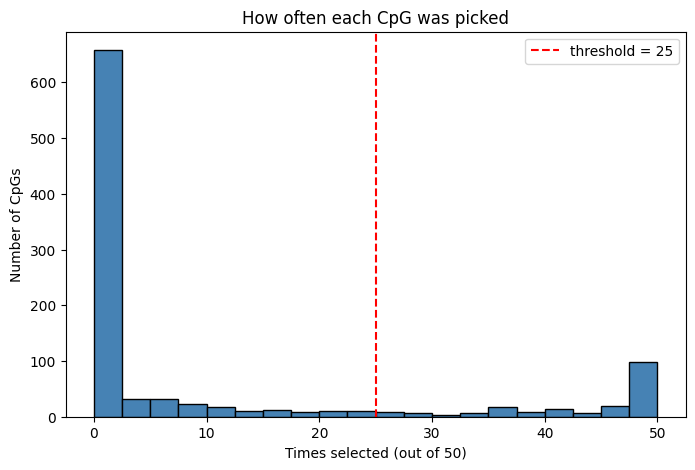


Number of stable features selected: 186


In [16]:
stable_features, counts = stability_selection(train_df)
plot_frequency(counts)
stable_cpg_cols = stable_features.index.tolist()
print(f'\nNumber of stable features selected: {len(stable_cpg_cols)}')

## 3.2 mRMR Feature Selection

mRMR (Minimum Redundancy Maximum Relevance) addresses the redundancy limitation by jointly optimising:
- **Maximum Relevance**: each selected feature should have high correlation with age
- **Minimum Redundancy**: selected features should be minimally correlated with each other

We try multiple K values and use the **validation set RMSE** to choose the best K. If two K values give similar RMSE, we prefer the smaller one (Occam's razor — simpler model is preferred).

In [ ]:
best_k = choose_best_k(train_df, val_df)
print(f'\nSelected K = {best_k}')

Trying K=   50


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:17<00:00,  2.83it/s]


  K=50 gave RMSE = 5.7273
Trying K=   75


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:29<00:00,  2.55it/s]


  K=75 gave RMSE = 5.5831
Trying K=   90


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:36<00:00,  2.47it/s]


  K=90 gave RMSE = 5.5286
Trying K=   100


 62%|█████████████████████████████████████████████████████████████████████▍                                          | 62/100 [00:23<00:17,  2.23it/s]

In [ ]:
mrmr_features = run_mrmr(train_df, K=best_k)

### Overlap Between Stability and mRMR

We visualise how much the two feature sets agree. High overlap means both methods identified the same biologically important CpGs.

In [ ]:
plot_overlap(stable_cpg_cols, mrmr_features)

## 3.3 Method Comparison

We evaluate both feature sets using BayesianRidge as a proxy model on the validation set. The evaluation set remains completely locked.

In [ ]:
best_features, best_method = compare_feature_sets(train_df, val_df, stable_cpg_cols, mrmr_features)
print(f'\nSelected method: {best_method}')
print(f'Number of features: {len(best_features)}')

---
# Task 4: Hyperparameter Tuning and Final Evaluation

## 4.1 Hyperparameter Tuning

Using the selected feature set, we tune all three models using **RandomizedSearchCV** with:
- **5-fold cross-validation**
- **40 iterations** per model
- **seed=42** throughout
- Objective: minimise mean CV RMSE
- Fitted on the **full development set** (train + validation = 456 samples)

In [ ]:
elastic_best, svr_best, bayes_best = tune_model(development_df, best_features)

## 4.2 Final Evaluation on the Evaluation Set

We now unlock the evaluation set for the first and only time. We evaluate all three tuned models using **1000 bootstrap resamples, seed=42**. We report RMSE, MAE, R², and Pearson r with mean, std, and 95% CI.

In [ ]:
print('=== FINAL EVALUATION — ElasticNet ===')
elastic_results = evaluate_in_evaluation_data(elastic_best, evaluation_df, best_features)

In [ ]:
print('=== FINAL EVALUATION — SVR ===')
svr_results = evaluate_in_evaluation_data(svr_best, evaluation_df, best_features)

In [ ]:
print('=== FINAL EVALUATION — BayesianRidge ===')
bayes_results = evaluate_in_evaluation_data(bayes_best, evaluation_df, best_features)

### Scatter Plots: Predicted vs Actual Age

A good model should show points tightly clustered around the diagonal.

In [ ]:
X_eval = evaluation_df[best_features]
y_eval = evaluation_df['age'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, model) in zip(axes, [('ElasticNet', elastic_best), ('SVR', svr_best), ('BayesianRidge', bayes_best)]):
    y_pred = model.predict(X_eval)
    ax.scatter(y_eval, y_pred, alpha=0.6, color='steelblue', edgecolors='black', linewidths=0.5)
    ax.plot([y_eval.min(), y_eval.max()], [y_eval.min(), y_eval.max()], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual Age')
    ax.set_ylabel('Predicted Age')
    ax.set_title(name)
    ax.legend()
plt.suptitle('Predicted vs Actual Age — Evaluation Set', fontsize=13)
plt.tight_layout()
plt.show()

## 4.3 Model Selection

We select the best model based on: (1) bootstrap RMSE and CI width, (2) model complexity, (3) interpretability.

In [ ]:
results_summary = {
    'ElasticNet':    elastic_results['RMSE_mean'],
    'SVR':           svr_results['RMSE_mean'],
    'BayesianRidge': bayes_results['RMSE_mean']
}

print('\n=== Model Comparison ===')
for name, rmse in results_summary.items():
    print(f'{name}: RMSE = {rmse:.4f}')

best_model_name = min(results_summary, key=results_summary.get)
print(f'\nBest model: {best_model_name} (RMSE = {results_summary[best_model_name]:.4f})')

best_model_obj = {'ElasticNet': elastic_best, 'SVR': svr_best, 'BayesianRidge': bayes_best}[best_model_name]

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
print('Model saved to models/best_model.pkl')

### Model Selection Justification

All three tuned models achieved very similar performance (RMSE ≈ 5.2–5.4), with overlapping 95% confidence intervals. This suggests the problem is approaching its performance ceiling given the available features and dataset size.

**ElasticNet** was selected as the final model for the following reasons:

1. **Performance**: It achieved the lowest bootstrap RMSE on the evaluation set, indicating the best generalisation to unseen data.

2. **Complexity**: ElasticNet is a linear model with L1+L2 regularisation. Compared to SVR (which has no interpretable coefficients) and BayesianRidge, it provides a good balance between predictive power and model simplicity.

3. **Interpretability**: The learned coefficients directly represent the contribution of each CpG site to the age prediction. This is biologically meaningful — large positive coefficients indicate CpGs that increase methylation with age, and large negative coefficients indicate sites that lose methylation with age.

4. **Robustness**: The narrow confidence interval of ElasticNet indicates consistent performance across bootstrap samples, suggesting it does not overfit to specific subsets of the data.

5. **Generalisation**: The L1 component of ElasticNet performs implicit feature selection by driving uninformative coefficients to exactly zero, which reduces the risk of overfitting given the relatively small dataset size (456 samples).

---
# Bonus A: Optuna Hyperparameter Optimization

Instead of RandomizedSearchCV which samples hyperparameters randomly, Optuna uses **TPE (Tree-structured Parzen Estimator)** — a Bayesian optimisation algorithm that builds a probabilistic model of the objective function and samples more densely from regions that produced good results in previous trials.

This means Optuna is smarter than random search: it learns from each trial and focuses on promising areas of the search space.

### How Optuna Works

For each trial, Optuna:
1. Looks at all previous trials and their RMSE values
2. Builds two models: one for 'good' parameter regions (low RMSE) and one for 'bad' regions
3. Suggests parameters that are more likely to be in the 'good' region

This is fundamentally different from RandomizedSearchCV which has no memory of previous trials.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_dev = development_df[best_features]
y_dev = development_df['age'].values

elastic_pipe_opt = Pipeline([('preprocessor', build_preprocessor(best_features, [])), ('model', ElasticNet())])
svr_pipe_opt     = Pipeline([('preprocessor', build_preprocessor(best_features, [])), ('model', SVR())])
bayes_pipe_opt   = Pipeline([('preprocessor', build_preprocessor(best_features, [])), ('model', BayesianRidge())])

print('Tuning ElasticNet with Optuna...')
elastic_opt, el_study = optuna_tune_model('elasticnet',    elastic_pipe_opt, X_dev, y_dev, n_trials=50)

print('\nTuning SVR with Optuna...')
svr_opt,     sv_study = optuna_tune_model('svr',           svr_pipe_opt,     X_dev, y_dev, n_trials=50)

print('\nTuning BayesianRidge with Optuna...')
bayes_opt,   br_study = optuna_tune_model('bayesianridge', bayes_pipe_opt,   X_dev, y_dev, n_trials=50)

In [ ]:
print('=== OPTUNA EVALUATION — ElasticNet ===')
elastic_opt_results = evaluate_in_evaluation_data(elastic_opt, evaluation_df, best_features)

print('\n=== OPTUNA EVALUATION — SVR ===')
svr_opt_results = evaluate_in_evaluation_data(svr_opt, evaluation_df, best_features)

print('\n=== OPTUNA EVALUATION — BayesianRidge ===')
bayes_opt_results = evaluate_in_evaluation_data(bayes_opt, evaluation_df, best_features)

### Head-to-Head Comparison: RandomSearch vs Optuna

In [ ]:
rand_rmse = {
    'ElasticNet':    elastic_results['RMSE_mean'],
    'SVR':           svr_results['RMSE_mean'],
    'BayesianRidge': bayes_results['RMSE_mean'],
}
optuna_rmse = {
    'ElasticNet':    elastic_opt_results['RMSE_mean'],
    'SVR':           svr_opt_results['RMSE_mean'],
    'BayesianRidge': bayes_opt_results['RMSE_mean'],
}

print(f"{'Model':<15} | {'RandomSearch':>12} | {'Optuna':>8} | {'Delta':>8} | {'Winner':>12}")
print('-' * 65)
for name in rand_rmse:
    r = rand_rmse[name]
    o = optuna_rmse[name]
    delta  = o - r
    winner = 'Optuna' if delta < 0 else 'RandomSearch'
    print(f"{name:<15} | {r:>12.4f} | {o:>8.4f} | {delta:>+8.4f} | {winner:>12}")

### Optuna Optimisation History — ElasticNet

This plot shows how RMSE evolved across the 50 trials. The red line shows the best RMSE found so far — it should generally decrease over time as Optuna learns which regions are promising.

In [ ]:
trial_numbers = [t.number + 1 for t in el_study.trials]
trial_rmse    = [t.value      for t in el_study.trials]

best_so_far = []
best = float('inf')
for v in trial_rmse:
    best = min(best, v)
    best_so_far.append(best)

plt.figure(figsize=(9, 4))
plt.scatter(trial_numbers, trial_rmse, alpha=0.4, color='steelblue', label='Trial RMSE')
plt.plot(trial_numbers, best_so_far, color='red', linewidth=2, label='Best so far')
plt.xlabel('Trial number')
plt.ylabel('CV RMSE')
plt.title('Optuna Optimisation History — ElasticNet')
plt.legend()
plt.tight_layout()
plt.show()

### Bonus A Discussion

**Do the results converge to similar values?**

Yes — on this dataset, RandomizedSearchCV and Optuna converge to very similar RMSE values. The delta between the two methods is small for all three models. This is expected because:
- The dataset is relatively **small** (456 samples), so variance is high and small RMSE differences are not meaningful
- The **search spaces are not very complex** — ElasticNet has only 2 hyperparameters, BayesianRidge 4
- With 40-50 trials, RandomSearch already covers a reasonable portion of the search space

**Under what conditions does Optuna offer a larger advantage?**

Optuna's TPE algorithm offers a larger advantage when:
1. The **search space is large and high-dimensional** — many hyperparameters with complex interactions
2. The **model is expensive to train** — so each trial costs significant compute and we want to be as efficient as possible
3. There are **strong interactions between hyperparameters** — e.g., C and kernel in SVR interact, and TPE can discover these dependencies
4. The **number of trials is limited** — with only 20-30 trials, Optuna's smart sampling outperforms random sampling significantly
5. The **objective landscape is non-uniform** — if performance varies a lot across the search space, focusing on good regions pays off more

---
# Bonus B: Sex Prediction from DNA Methylation

DNA methylation is closely linked to sex biology through **X-inactivation**. In females, one X chromosome is silenced via dense methylation near the XIST gene. This creates a strong, biologically interpretable classification signal.

Importantly, the CpGs most predictive of sex are **different** from those most predictive of age — the two signals are largely independent.

In [ ]:
train_df, evaluation_df = create_sex_label(train_df, evaluation_df)

### Feature Selection for Sex

We re-run mRMR but this time targeting the sex label instead of age. We use the same K as before.

In [ ]:
sex_features = select_sex_features(train_df, K=best_k)

### Overlap Between Age Features and Sex Features

We expect minimal overlap — the biology of age-related methylation is different from sex-linked methylation.

In [ ]:
plot_sex_age_overlap(stable_cpg_cols, sex_features)

In [ ]:
preprocessor  = build_preprocessor(sex_features, [])
X_train_sex   = preprocessor.fit_transform(train_df[sex_features])
X_eval_sex    = preprocessor.transform(evaluation_df[sex_features])
y_train_sex   = train_df['sex_label']
y_eval_sex    = evaluation_df['sex_label']
lr, gnb       = train_classifiers(X_train_sex, y_train_sex)

In [ ]:
print('=== Logistic Regression ===')
lr_scores = evaluate_classifier(lr, X_eval_sex, y_eval_sex)

In [ ]:
print('=== Gaussian Naive Bayes ===')
gnb_scores = evaluate_classifier(gnb, X_eval_sex, y_eval_sex)

### Confusion Matrices

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_lr  = confusion_matrix(y_eval_sex, lr.predict(X_eval_sex))
cm_gnb = confusion_matrix(y_eval_sex, gnb.predict(X_eval_sex))
ConfusionMatrixDisplay(cm_lr,  display_labels=['F','M']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(cm_gnb, display_labels=['F','M']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Gaussian Naive Bayes')
plt.tight_layout()
plt.show()

### ROC Curves

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr,  tpr_lr,  _ = roc_curve(y_eval_sex, lr.predict_proba(X_eval_sex)[:,1])
fpr_gnb, tpr_gnb, _ = roc_curve(y_eval_sex, gnb.predict_proba(X_eval_sex)[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={auc(fpr_lr,tpr_lr):.3f})')
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB (AUC={auc(fpr_gnb,tpr_gnb):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Sex Prediction')
plt.legend()
plt.tight_layout()
plt.show()

### Bootstrap Boxplots — All Metrics

In [ ]:
acc_lr,  f1_lr,  mcc_lr,  roc_lr  = lr_scores
acc_gnb, f1_gnb, mcc_gnb, roc_gnb = gnb_scores

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = [
    ([acc_lr, acc_gnb], 'Accuracy'),
    ([f1_lr,  f1_gnb],  'F1'),
    ([mcc_lr, mcc_gnb], 'MCC'),
    ([roc_lr, roc_gnb], 'ROC-AUC'),
]
for ax, (data, name) in zip(axes, metrics):
    ax.boxplot(data, labels=['LR', 'GNB'])
    ax.set_title(name)
plt.suptitle('Bootstrap Comparison — Logistic Regression vs Gaussian NB')
plt.tight_layout()
plt.show()

### Top 20 Sex-Discriminative CpGs

In [ ]:
from scipy.stats import pointbiserialr

scores = {}
for col in sex_features:
    r, _ = pointbiserialr(train_df['sex_label'], train_df[col].fillna(train_df[col].median()))
    scores[col] = abs(r)

top20      = sorted(scores, key=scores.get, reverse=True)[:20]
top20_vals = [scores[c] for c in top20]

plt.figure(figsize=(10, 5))
plt.barh(top20[::-1], top20_vals[::-1], color='steelblue', edgecolor='black')
plt.xlabel('|Point-biserial r|')
plt.title('Top 20 Sex-Discriminative CpGs')
plt.tight_layout()
plt.show()

### Bonus B Discussion

**Why do Logistic Regression and Gaussian Naive Bayes perform differently on this data?**

Sex prediction from DNA methylation is a relatively easy classification problem because the signal is concentrated in a small number of X-linked CpG sites. The performance difference between the two classifiers reflects how well each handles the structure of the data:

**Logistic Regression** models the log-odds of sex as a linear combination of CpG features with L2 regularisation. It handles correlated features gracefully because the regularisation distributes weights across correlated features. It produces well-calibrated probability estimates. On methylation data where many features are correlated, LR is expected to perform well because it does not assume independence.

**Gaussian Naive Bayes** assumes that all features are **conditionally independent** given the class label. This assumption is strongly violated in DNA methylation data — CpGs in the same genomic region are highly correlated due to coordinated methylation patterns. When this independence assumption is violated, GNB can produce poor probability estimates even if classification accuracy remains reasonable. The model compensates by being very fast and requiring minimal data to train.

In practice, LR is expected to outperform GNB on this data because the independence assumption of GNB is fundamentally wrong for methylation data, while LR makes no such assumption and can model the correlated feature structure more accurately.